# 1. Incarcarea datelor

In [1]:
from google.colab import files

uploaded = files.upload()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data (1).csv


Nota: Numele fisierului in lucru este "healthcare-dataset-stroke-data.csv". Nu trebuie incarcat altceva.

In [2]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning) #ignorarea avertismentelor nerelevante proiectului

import os

print(os.listdir("/content")) #calea in care se regaseste fisierul

import pandas as pd

db = pd.read_csv("/content/healthcare-dataset-stroke-data.csv")
db

['.config', 'healthcare-dataset-stroke-data.csv', 'healthcare-dataset-stroke-data (1).csv', 'sample_data']


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


# 2. Explorarea si intelegerea datelor

## 2.1. Observatii in urma explorarii data-setului

In [3]:
db.info()
display(db.describe())
db.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
display(db.isnull().sum())
bmi_lipsa = db["bmi"].isnull().sum()
print(f"Coloana bmi are un numar de {bmi_lipsa} date lipsa.")

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


Coloana bmi are un numar de 201 date lipsa.


In [5]:
coloane_categorice = list(db.select_dtypes(include=['object', 'category']).columns)
print(coloane_categorice)

def afisare_coloane_categorice():
  for coloana in coloane_categorice:
    print(f"\n{coloana}")
    print(db[coloana].unique())

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


Note:
*   Baza noastra de date cuprinde un numar de 12 coloane, cu 5110 de intrari.
*   Dintre cele 12 coloane, 5 cuprind date categorice (gender, ever_married, work_type, residence_type, smoking_status).
*   Se pot observa: *date aparent nesemnificative* (coloana id este doar un indificator), *date lipsa* (in coloana bmi), *valori extreme* (bmi foarte mic sau foarte mare, avg_glucose_level specific cazurilor de diabet).



## 2.2. Dezechilibre intre clase

,proportion
stroke,
0,95.127202
1,4.872798


/tmp/ipykernel_32533/965792423.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Negativ", "Pozitiv"])


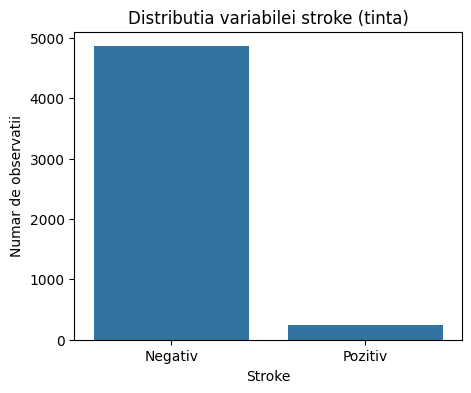

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

display(db["stroke"].value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))
ax = sns.countplot(x="stroke", data=db)
plt.title("Distributia variabilei stroke (tinta)")
ax.set_xticklabels(["Negativ", "Pozitiv"])
plt.xlabel("Stroke")
plt.ylabel("Numar de observatii")
plt.show()


--- gender ---
gender
Female    58.59
Male      41.39
Other      0.02

--- ever_married ---
ever_married
Yes    65.62
No     34.38

--- work_type ---
work_type
Private          57.24
Self-employed    16.03
children         13.44
Govt_job         12.86
Never_worked      0.43

--- Residence_type ---
Residence_type
Urban    50.8
Rural    49.2

--- smoking_status ---
smoking_status
never smoked       37.03
Unknown            30.22
formerly smoked    17.32
smokes             15.44


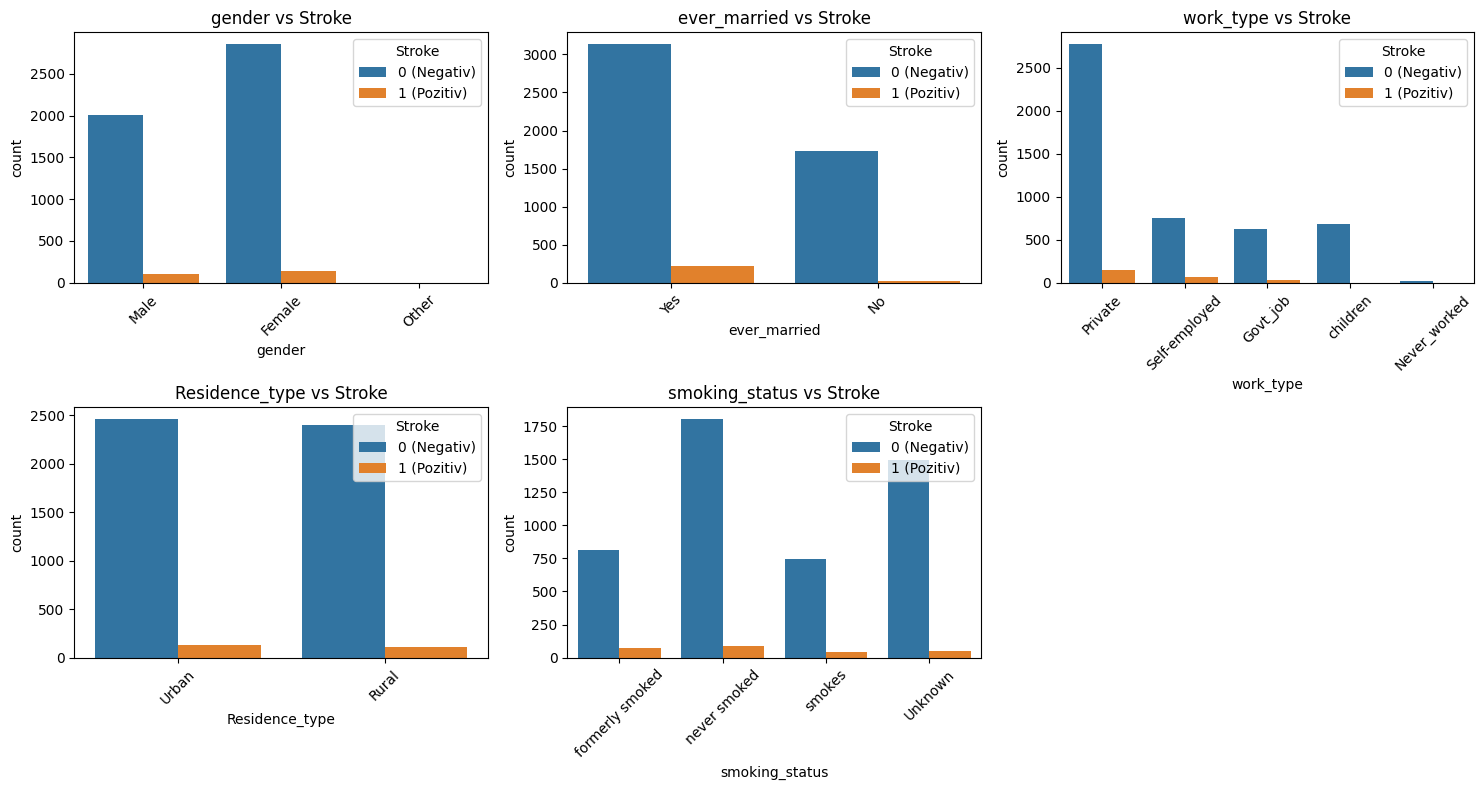

In [30]:
for coloana in coloane_categorice:
    print(f"\n--- {coloana} ---")
    distributie = db[coloana].value_counts(normalize=True).mul(100).round(2)
    print(distributie.to_string())

plt.figure(figsize=(15, 8))

for i, coloana in enumerate(coloane_categorice):
    plt.subplot(2, 3, i + 1)

    ax = sns.countplot(x=coloana, hue="stroke", data=db)
    ax.legend(["0 (Negativ)", "1 (Pozitiv)"], title="Stroke")
    plt.title(f"{coloana} vs Stroke")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Distributia celorlalte variabile cateogirce este relativ proportionala cu distributia variabilei tinta.

# 3. Preprocesarea datelor

## 3.1. Tratarea datelor extreme

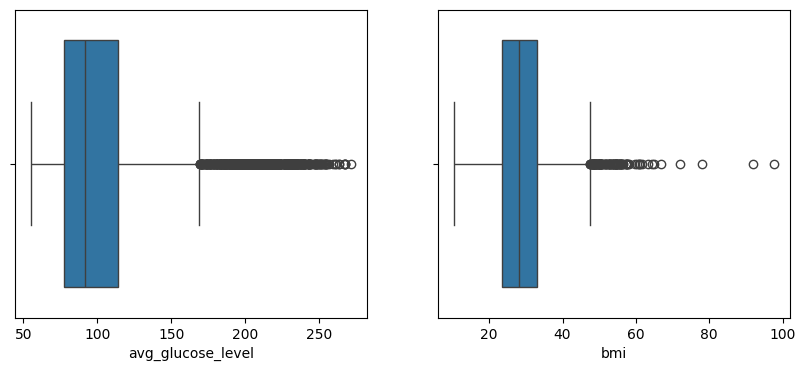

In [8]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=db["avg_glucose_level"])

plt.subplot(1, 2, 2)
sns.boxplot(x=db["bmi"])

plt.show()

Nota: Se observa foarte multi outlieri pentru cele 2 coloane. Am ales sa nu modific datele din coloanele avg_glucose_level si bmi. Valorile foarte mari pot fi explicate medical (prezenta diabetului, obezitate morbida).

## 3.2. Separarea datelor

In [9]:
X = db.drop(columns=["stroke", "id"]) # datele de intrare care ne vor ajuta sa facem predictia
y = db["stroke"] # variabila tinta

Nota: Renuntam la coloana "id", aceasta neavand nicio influenta pentru modelul nostru. Este doar folosita ca identificator.

## 3.3. Train/test split

Impartim datele in date folosite pentru antreanarea modelului (x_train, y_train) si date pe care modelul nu le-a vazut in timpul antrenarii si pe care le folosim la evaluare (x_test, y_test).

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify=y
                                                    )

## 3.4. Tratarea coloanelor categorice si datelor lipsa

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(
    transformers=[("categorice", OneHotEncoder(handle_unknown="ignore"),
                  coloane_categorice),
                  ("bmi", SimpleImputer(strategy="median"),
                  ["bmi"]),
                  ],
                  remainder="passthrough"
)

Prin folosirea OneHotEncoding transformam variabilele categorice in variabile numerice, si evitam ca anumite date sa fie mai influente. Pentru valorile lipsa din coloana "bmi" am ales sa fac imputarea cu mediana, aceasta fiind mai putin influentata decat media de valorile extreme.

# 4. Antrenarea unui model de baza

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model1 = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)

Am construit un Piepline care foloseste datele prepocesate conform schemei de mai inainte si aplica un clasificator. Acest model va incerca sa invete relatia dintre datele de intrare si raspunsurile corecte.

## 4.1. Evaluarea modelului

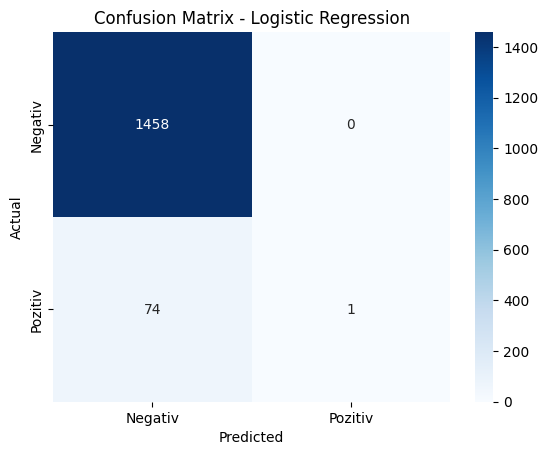

In [13]:
from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm1,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negativ", "Pozitiv"],
    yticklabels=["Negativ", "Pozitiv"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Cu ajutorul ConfusionMatrix se poate observa:
- modelul a ratat 74 de cazuri pozitive
- deoarece in dataset avem un dezechilibru intre clase (un numar foarte mare de intrari negative), modelul tinde sa aloce datelor doar eticheta negativa.

In [14]:
from sklearn.metrics import recall_score, f1_score

recall = recall_score(y_test, y_pred) #calculeaza ponderea cazurilor corect prezise
f1 = f1_score(y_test, y_pred) #scor care combina precizia si recall-ul

print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

Recall: 0.01
F1-score: 0.03


## 4.2. Tratarea dezechilibrului intre clase

Folosim parametrul class_weight astfel incat modelul sa nu acorde o importanta mai mare clasei dominante.

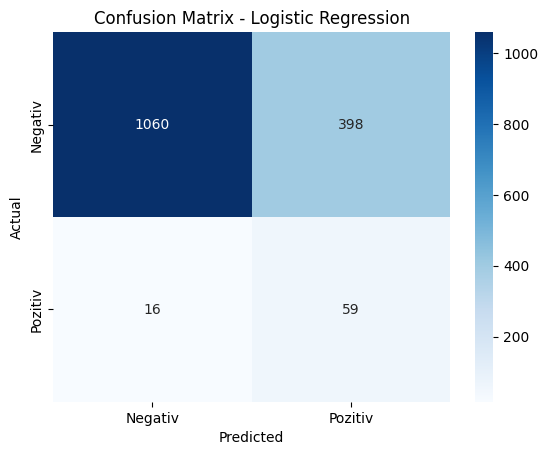

Recall: 0.79
F1-score: 0.22


In [15]:
model2 = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000,
                                      class_weight="balanced"))
])

model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)
recall2 = recall_score(y_test, y_pred)
f12 = f1_score(y_test, y_pred)

cm2 = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negativ", "Pozitiv"],
    yticklabels=["Negativ", "Pozitiv"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

print(f"Recall: {recall2:.2f}")
print(f"F1-score: {f12:.2f}")

Se observa o scaderea a predictiei fals negative, acesta fiind principalul obiectiv in determinarea modelului optim. O predictie fals negativa inseamna ca modelul nostru rateaza predictia aparitiei infarctului.

In [16]:
fn1 = cm1[1, 0]
fn2 = cm2[1, 0]
fp1 = cm1[0, 1]
fp2 = cm2[0, 1]

scores1 = pd.DataFrame({"Model": ["LogisticRegression", "LogisticRegression + class weight"],
                        "Recall": [recall, recall2],
                        "F1-score": [f1, f12],
                        "FN": [fn1, fn2],
                        "FP": [fp1, fp2]})
scores1.round(2)

,Model,Recall,F1-score,FN,FP
0,LogisticRegression,0.01,0.03,74,0
1,LogisticRegression + class weight,0.79,0.22,16,398


Desi dupa interventia noastra a scazul numarul de predictii fals negative, creste de asemenea si numarul de predictii fals pozitive. Prezicem riscul aparitiei infarctului acolo unde nu este cazul.

# 5. Antrenarea altor modele

## 5.1. RandomForest

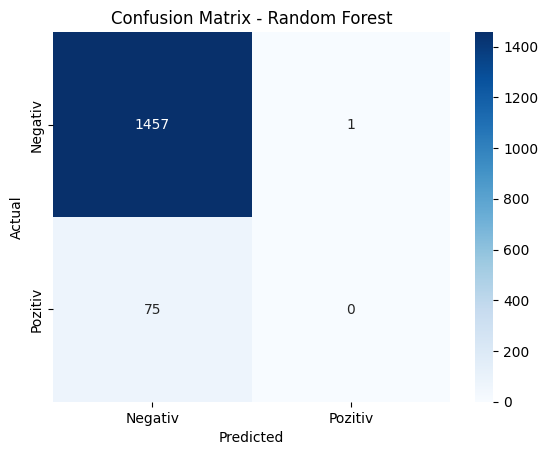

Recall: 0.00
F1-score: 0.00


In [17]:
from sklearn.ensemble import RandomForestClassifier

model3 = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))])

model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)
recall3 = recall_score(y_test, y_pred3)
f13 = f1_score(y_test, y_pred3)

cm3 = confusion_matrix(y_test, y_pred3)

sns.heatmap(
    cm3,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negativ", "Pozitiv"],
    yticklabels=["Negativ", "Pozitiv"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

print(f"Recall: {recall3:.2f}")
print(f"F1-score: {f13:.2f}")

RandomForest nu identifica niciun caz pozitiv.

## 5.2. RamdomForest + GridSearch

Am incercat optimizarea hiperparametrilor modelului de RandomForest cu un cross-validation stratificat in 5 fold-uri. Testarea s-a facut pe 32 de combinatii de parametrii. S-a ales configuratia cea mai buna in functie de F1-score, aceasta metrica fiind potrivita unei clasificari, mai ales cand clasele sunt dezechilibrate.

In [18]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
    "classifier__class_weight": ["balanced", None]
}

grid_search = GridSearchCV(
    estimator=model3,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Cei mai buni parametri:", grid_search.best_params_)
print(f"\nCel mai bun F1-score CV: {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Cei mai buni parametri: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

Cel mai bun F1-score CV: 0.156


Prin aplicarea GridSearch asupra modelului RandomForest am imbunatatit nesemnificativ performanta acestuia.

## 5.3. XGBoost



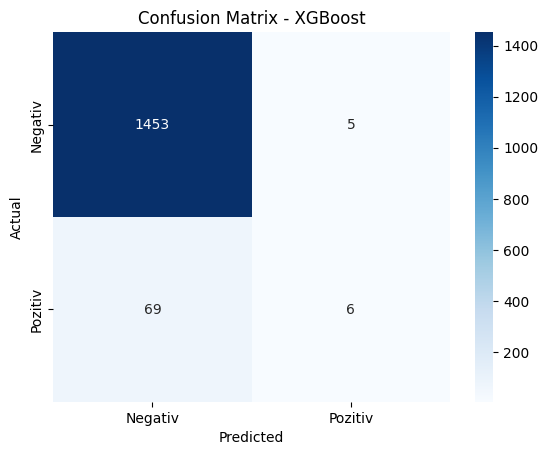

Recall: 0.08
F1-score: 0.14


In [19]:
from xgboost import XGBClassifier

model4 = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42))])

model4.fit(X_train, y_train)
y_pred4 = model4.predict(X_test)
recall4 = recall_score(y_test, y_pred4)
f14 = f1_score(y_test, y_pred4)

cm4 = confusion_matrix(y_test, y_pred4)

sns.heatmap(
    cm4,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negativ", "Pozitiv"],
    yticklabels=["Negativ", "Pozitiv"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

print(f"Recall: {recall4:.2f}")
print(f"F1-score: {f14:.2f}")

## 5.4.XGBoost + GridSearch

Incercarea echilibrarii claselor prin folosirea hipermaterului "*scale positive weight*" influenteaza substantial precizia modelului.

19.557471264367816


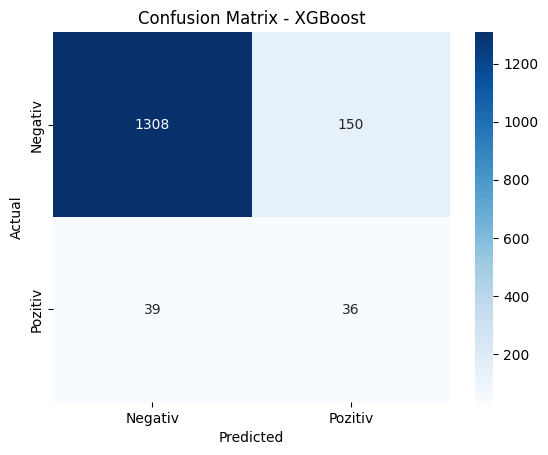

Recall: 0.48
F1-score: 0.28


In [20]:
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print(scale_pos_weight)

model5 = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        scale_pos_weight=scale_pos_weight))])

model5.fit(X_train, y_train)
y_pred5 = model5.predict(X_test)
recall5 = recall_score(y_test, y_pred5)
f15 = f1_score(y_test, y_pred5)

cm5 = confusion_matrix(y_test, y_pred5)

sns.heatmap(
    cm5,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negativ", "Pozitiv"],
    yticklabels=["Negativ", "Pozitiv"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

print(f"Recall: {recall5:.2f}")
print(f"F1-score: {f15:.2f}")

In [21]:
cv2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid2 = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 5],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__scale_pos_weight": [10, 15, scale_pos_weight, 25]
}


grid_search2 = GridSearchCV(
    estimator=model5,
    param_grid=param_grid2,
    cv=cv2,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search2.fit(X_train, y_train)

print("Cei mai buni parametri:", grid_search2.best_params_)
print(f"\nCel mai bun F1-score CV: {grid_search2.best_score_:.3f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Cei mai buni parametri: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': 10}

Cel mai bun F1-score CV: 0.268


In [22]:
fn3 = cm3[1, 0]
fn5 = cm5[1, 0]
fp3 = cm3[0, 1]
fp5 = cm5[0, 1]

scores2 = pd.DataFrame({"Model": ["LogisticRegression",
                                  "LogisticRegression + class weight",
                                  "RandomForest",
                                  "RandomForest + GridSearchCV",
                                  "XGBoost + scale_pos_weight",
                                  "XGBoost + GridSearchCV"],
                        "Recall": [recall, recall2, recall3, None, recall5, None],
                        "F1-score": [f1, f12, f13, grid_search.best_score_, f15, grid_search2.best_score_],
                        "FN": [fn1, fn2, fn3, None, fn5, None],
                        "FP": [fp1, fp2, fp3, None, fp5, None]})
scores2.style.format({
    "Recall": "{:.2f}",
    "F1-score": "{:.2f}",
    "FN": "{:.0f}",
    "FP": "{:.0f}"
    },
    na_rep="-")

,Model,Recall,F1-score,FN,FP
0,LogisticRegression,0.01,0.03,74,0
1,LogisticRegression + class weight,0.79,0.22,16,398
2,RandomForest,0.00,0.00,75,1
3,RandomForest + GridSearchCV,-,0.16,-,-
4,XGBoost + scale_pos_weight,0.48,0.28,39,150
5,XGBoost + GridSearchCV,-,0.27,-,-


# 6. Feature Importance

## 6.1. Varsta

In [23]:
print(X["age"].describe())
print(X["age"].sort_values().head(10))

db[db["age"] < 18]["stroke"].value_counts()

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64
1614    0.08
3295    0.08
3618    0.16
3968    0.16
4021    0.16
3392    0.24
2898    0.24
4293    0.24
996     0.24
1999    0.24
Name: age, dtype: float64


,count
stroke,
0,854
1,2


Datele de intrare pentru varsta sunt fractionare. Asta indica date intentionate (0.08 poate corespunde unei varste de 1 luna). De asemenea datele sunt foarte dezechilibrate pentru clasa copiiilor (854 din 856 de cazuri au "stroke" 0). Acest lucru contribuie la predictia preponderent negativa.  

## 6.2. Interactiunea altor boli

In [24]:
interactiune = (
    db.groupby(["hypertension", "heart_disease"])["stroke"]
      .agg(["count", "sum"])
      .reset_index()
)

interactiune

,hypertension,heart_disease,count,sum
0,0,0,4400,149
1,0,1,212,34
2,1,0,434,53
3,1,1,64,13


Se observa ca atunci cand nu sunt prezente alte boli cardiace, nu apare nici infarctul. De asemenea aceasta combinatie de date domina data-setul, fiind un alt motiv pentru numarul mic de date cu "stroke" pozitiv. Celelalte combinatii sunt slab reprezentate pentru a putea emite teorii.

In [25]:
print("Numar de valori cu glicemie mare: ", (db["avg_glucose_level"] >= 126).sum())

display(db[db["avg_glucose_level"] >= 126]["stroke"].value_counts())
display(db[db["avg_glucose_level"] < 126]["stroke"].value_counts())

Numar de valori cu glicemie mare:  981


,count
stroke,
0,881
1,100


,count
stroke,
0,3980
1,149


Se observa ca persoanele cu un nivel de glicemie peste limita superioara au o proportie de AVC mai mare.

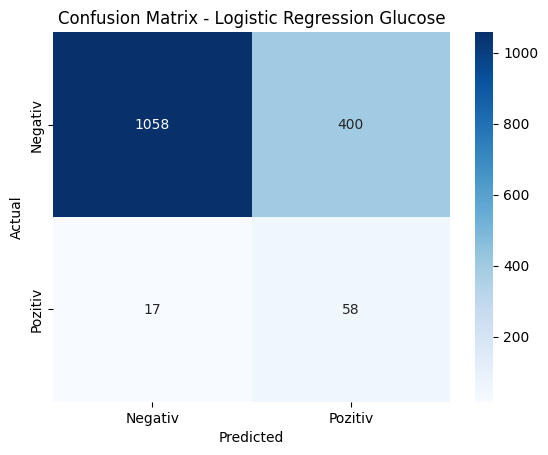

Recall: 0.77
F1-score: 0.22


In [26]:
from sklearn.preprocessing import StandardScaler

db["high_glucose"] = (db["avg_glucose_level"] >= 126).astype(int)

coloane_numerice = [
    "age",
    "avg_glucose_level",
    "high_glucose"
]

X = db.drop(columns=["stroke", "id"])
y = db["stroke"]

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify=y
                                                    )

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorice",
            OneHotEncoder(handle_unknown="ignore"),
            coloane_categorice
        ),
        (
            "bmi",
             Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            ["bmi"]
        ),
        (
            "numerice",
            StandardScaler(),
            coloane_numerice
        )
    ],
    remainder="passthrough"
)

model2_glucose = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000,
                                      class_weight="balanced"))
])

model2_glucose.fit(X_train, y_train)
y_pred_glucose = model2_glucose.predict(X_test)
recall2_glucose = recall_score(y_test, y_pred_glucose)
f12_glucose = f1_score(y_test, y_pred_glucose)

cm2_glucose = confusion_matrix(y_test, y_pred_glucose)

sns.heatmap(
    cm2_glucose,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negativ", "Pozitiv"],
    yticklabels=["Negativ", "Pozitiv"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression Glucose")
plt.show()

print(f"Recall: {recall2_glucose:.2f}")
print(f"F1-score: {f12_glucose:.2f}")

In [27]:
fn1 = cm1[1, 0]
fn2 = cm2[1, 0]
fp1 = cm1[0, 1]
fp2 = cm2[0, 1]
fn_glucose = cm2_glucose [1, 0]
fp_glucose = cm2_glucose [0, 1]

scores1 = pd.DataFrame({"Model": ["LogisticRegression", "LogisticRegression + class weight", "LogisticRegression + class weight + high_glucose + StandarScaler"],
                        "Recall": [recall, recall2, recall2_glucose],
                        "F1-score": [f1, f12, f12_glucose],
                        "FN": [fn1, fn2, fn_glucose],
                        "FP": [fp1, fp2, fp_glucose]})
scores1.round(2)

,Model,Recall,F1-score,FN,FP
0,LogisticRegression,0.01,0.03,74,0
1,LogisticRegression + class weight,0.79,0.22,16,398
2,LogisticRegression + class weight + high_gluco...,0.77,0.22,17,400


In final, chiar si cu adaugarea acelei caracteristici, nu am adus o imbunatatire reala.

# 7. AutoML

Am folosit FLAML pentru a compara sapte algoritmi de clasificare. Acesta a ales cel mai bun model si configuratia in functie de F1-score, intr-un timp de cautare de 120 de secunde.

In [28]:
# !pip -q install "flaml[automl]" mlflow
from flaml import AutoML

automl = AutoML()
automl.fit(
    X_train, y_train,
    task="classification",
    metric="f1",
    time_budget=120, #timp de cautare
    estimator_list=[
    "lgbm", #LightGBM
    "rf", #RandomForest
    "xgboost",
    "xgb_limitdepth", #XGBoost cu limitdepth
    "extra_tree", #ExtraTrees, similar rf
    "histgb", #HistGradientBoosting
    ],
    seed=42,
    verbose=0,
)

y_pred = automl.predict(X_test)
f1_automl= f1_score(y_test, y_pred)

print("Model ales de FLAML:", automl.best_estimator)
print("Configuratia aleasa:", automl.best_config)
print("F1-score:", round(f1_automl, 3))

Model ales de FLAML: xgb_limitdepth
Configuratia aleasa: {'n_estimators': 26, 'max_depth': 9, 'min_child_weight': np.float64(3.657029136787044), 'learning_rate': 1.0, 'subsample': np.float64(0.5711873050467785), 'colsample_bylevel': 1.0, 'colsample_bytree': np.float64(0.919565824875532), 'reg_alpha': np.float64(0.0026784891535010275), 'reg_lambda': np.float64(0.4807894799919493)}
F1-score: 0.145
